<center>
    
## Childcare Costs Analysis
## Medium 3 (Explainer Video)
## Arulsree Mozhi, TS

</center>

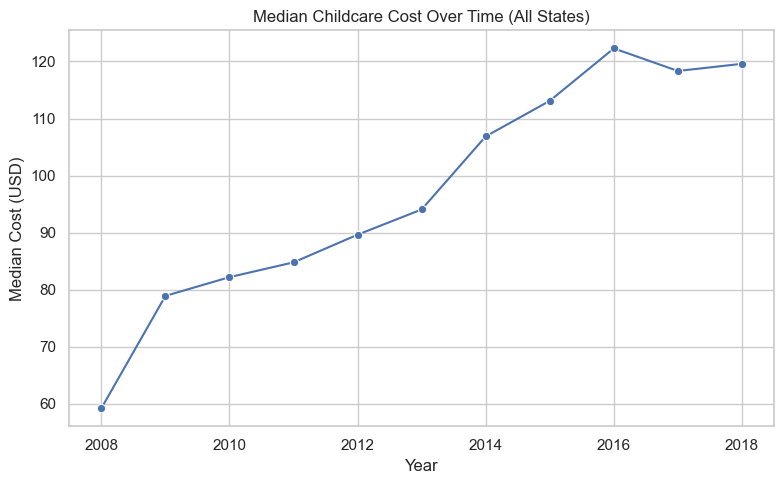

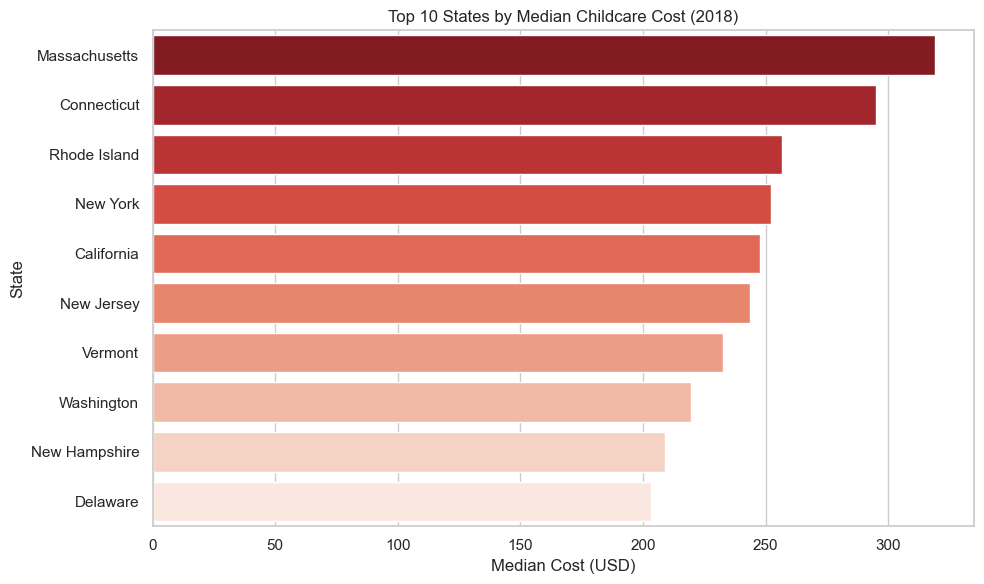

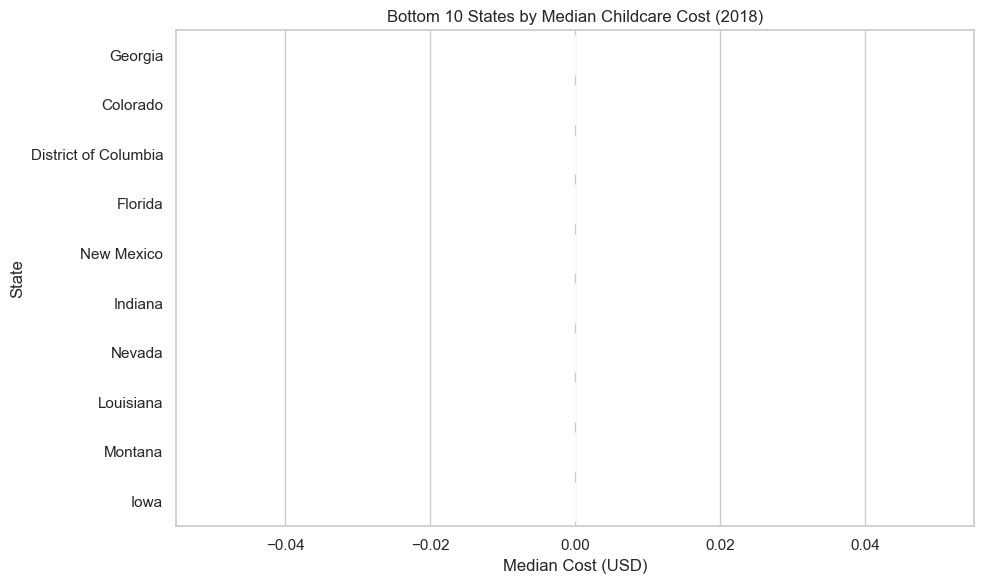

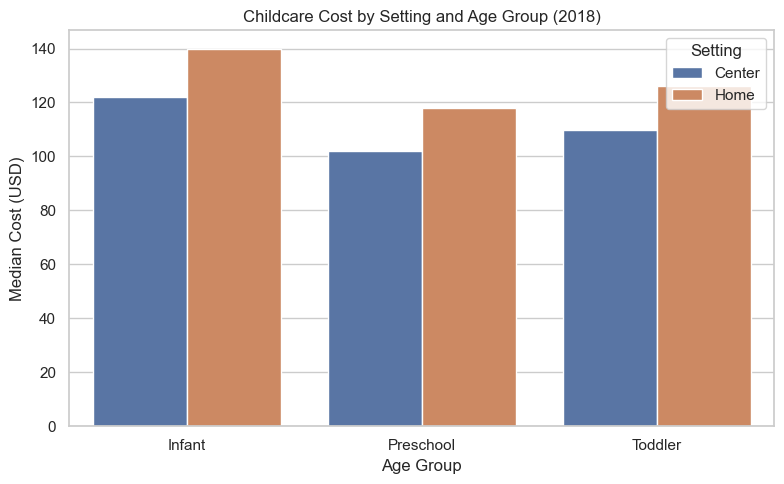

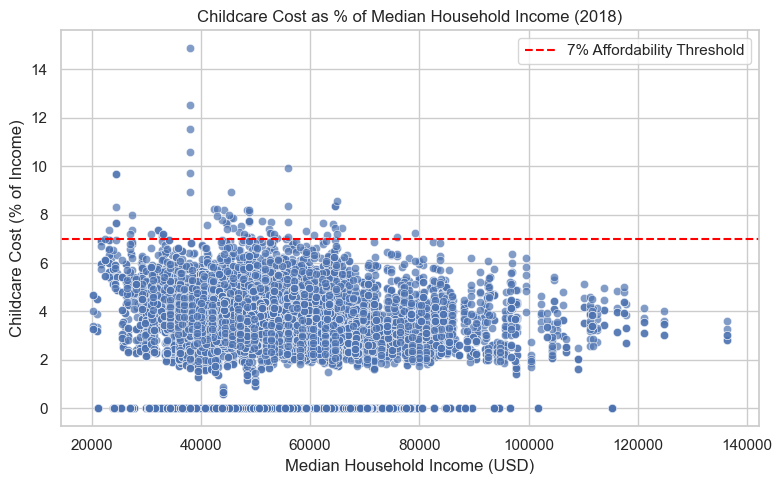

All visuals saved in folder: Medium 3 Visuals


In [8]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create folder to save visuals
output_folder = 'Medium 3 Visuals'
os.makedirs(output_folder, exist_ok=True)

# Load data
df = pd.read_excel('../Data/NationalDB_ChildCare_Cleaned.xlsx')

# Clean and prepare
df = df.dropna(subset=['Year', 'State', 'Median_Cost', 'MHI', 'Setting', 'Age_Group'])
df['Median_Cost'] = pd.to_numeric(df['Median_Cost'], errors='coerce')
df['MHI'] = pd.to_numeric(df['MHI'], errors='coerce')

# Set seaborn style
sns.set(style="whitegrid")

# Scene 2: Rising Costs - Median Childcare Cost by Year (All States)
yearly_cost = df.groupby('Year')['Median_Cost'].mean().reset_index()
plt.figure(figsize=(8,5))
sns.lineplot(data=yearly_cost, x='Year', y='Median_Cost', marker='o')
plt.title('Median Childcare Cost Over Time (All States)')
plt.ylabel('Median Cost (USD)')
plt.xlabel('Year')
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'rising_costs_linechart.png'))
plt.show()

# Scene 3: Where You Live Matters - Median Childcare Cost by State (Most Recent Year)
latest_year = df['Year'].max()
df_latest = df[df['Year'] == latest_year].copy()  # <-- Make a copy here

state_cost = df_latest.groupby('State')['Median_Cost'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=state_cost.head(10), y='State', x='Median_Cost', palette='Reds_r')
plt.title(f'Top 10 States by Median Childcare Cost ({latest_year})')
plt.xlabel('Median Cost (USD)')
plt.ylabel('State')
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'top10_states_cost.png'))
plt.show()

plt.figure(figsize=(10,6))
sns.barplot(data=state_cost.tail(10), y='State', x='Median_Cost', palette='Blues')
plt.title(f'Bottom 10 States by Median Childcare Cost ({latest_year})')
plt.xlabel('Median Cost (USD)')
plt.ylabel('State')
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'bottom10_states_cost.png'))
plt.show()

# Scene 4: What Drives Costs? - Cost Variation by Setting and Age Group
setting_age_cost = df_latest.groupby(['Setting', 'Age_Group'])['Median_Cost'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=setting_age_cost, x='Age_Group', y='Median_Cost', hue='Setting')
plt.title(f'Childcare Cost by Setting and Age Group ({latest_year})')
plt.ylabel('Median Cost (USD)')
plt.xlabel('Age Group')
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'cost_by_setting_age.png'))
plt.show()

# Scene 5: Affordability Challenge - Scatter Plot Cost vs Median Household Income (% of Income)
df_latest.loc[:, 'Cost_Percent_Income'] = (df_latest['Median_Cost'] * 12) / df_latest['MHI'] * 100  # fixed with .loc

plt.figure(figsize=(8,5))
sns.scatterplot(data=df_latest, x='MHI', y='Cost_Percent_Income', alpha=0.7)
plt.axhline(7, color='red', linestyle='--', label='7% Affordability Threshold')
plt.title(f'Childcare Cost as % of Median Household Income ({latest_year})')
plt.xlabel('Median Household Income (USD)')
plt.ylabel('Childcare Cost (% of Income)')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'cost_vs_income_scatter.png'))
plt.show()

print(f"All visuals saved in folder: {output_folder}")
